In [1]:
import numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
len_dataset = {'abundance_WT2D': 381,
               'abundance_cirrhosis--stagediscovery': 520,
               'abundance_cirrhosis--stagevalidation': 394,
               'abundance_ibd': 443,
               'abundance_obesity': 465,
               'abundance_t2d': 572
               }

In [21]:
stat_df = pd.read_csv('/data/projects/deepintegromics/analyses/3.tabpfn/metagen_foundation_models/data_transformations/stats_results/statistical_results_final.csv')

In [22]:
stat_df.dataset.unique()

array(['abundance_WT2D', 'abundance_cirrhosis--stagediscovery',
       'abundance_cirrhosis--stagevalidation', 'abundance_ibd',
       'abundance_obesity', 'abundance_t2d'], dtype=object)

In [23]:
stat_df.head()

,dataset,model,perturbation,param_value,auroc_baseline,auroc_ood,delta_auroc,p_value,p_value_fdr,significant
0,abundance_WT2D,ContextTab,densification,0.133,0.7745,0.7163,0.0581,0.1158,0.332175,False
1,abundance_WT2D,ContextTab,densification,0.255,0.7745,0.7067,0.0678,0.0666,0.238567,False
2,abundance_WT2D,ContextTab,densification,0.378,0.7745,0.7376,0.0369,0.2365,0.497895,False
3,abundance_WT2D,ContextTab,densification,0.501,0.7745,0.7400,0.0344,0.1119,0.323566,False
4,abundance_WT2D,ContextTab,densification,0.623,0.7745,0.7464,0.0281,0.2656,0.537385,False


In [24]:
stat_df_significant = stat_df[stat_df.significant]

In [25]:
stat_df_significant[['model', 'perturbation']].drop_duplicates()

,model,perturbation
27,RF,remove_features
60,TabICL,densification
101,XGBoost,densification
120,ContextTab,densification
140,RF,densification
160,TabDPT,densification
169,TabDPT,remove_features
200,TabPFN,densification
209,TabPFN,remove_features
219,TabPFN,sparsity


In [26]:
stat_df_significant[(stat_df_significant.perturbation == 'densification') & (stat_df_significant.model == 'TabICL')]

,dataset,model,perturbation,param_value,auroc_baseline,auroc_ood,delta_auroc,p_value,p_value_fdr,significant
60,abundance_WT2D,TabICL,densification,0.133,0.7977,0.5674,0.2304,0.0022,0.029333,True
61,abundance_WT2D,TabICL,densification,0.255,0.7977,0.5564,0.2413,0.0012,0.020571,True
62,abundance_WT2D,TabICL,densification,0.378,0.7977,0.6025,0.1953,0.0049,0.049690,True
180,abundance_cirrhosis--stagediscovery,TabICL,densification,0.138,0.9390,0.8315,0.1075,0.0001,0.003600,True
183,abundance_cirrhosis--stagediscovery,TabICL,densification,0.521,0.9390,0.8950,0.0440,0.0042,0.045818,True
420,abundance_ibd,TabICL,densification,0.135,0.8739,0.6226,0.2513,0.0000,0.000000,True
421,abundance_ibd,TabICL,densification,0.261,0.8739,0.6744,0.1995,0.0002,0.006545,True
422,abundance_ibd,TabICL,densification,0.386,0.8739,0.7059,0.1680,0.0015,0.022979,True
541,abundance_obesity,TabICL,densification,0.267,0.6973,0.5673,0.1300,0.0020,0.028235,True
542,abundance_obesity,TabICL,densification,0.396,0.6973,0.5756,0.1217,0.0031,0.037831,True


In [27]:
stat_df_significant[(stat_df_significant.perturbation == 'remove_features') & (stat_df_significant.model == 'XGBoost')][['dataset','param_value', 'delta_auroc']]

,dataset,param_value,delta_auroc
226,abundance_cirrhosis--stagediscovery,k=116 / highest_abundance,0.0681
227,abundance_cirrhosis--stagediscovery,k=144 / highest_abundance,0.0692
228,abundance_cirrhosis--stagediscovery,k=173 / highest_abundance,0.0892
229,abundance_cirrhosis--stagediscovery,k=202 / highest_abundance,0.0934
230,abundance_cirrhosis--stagediscovery,k=231 / highest_abundance,0.0973


In [28]:
stat_df_significant_dataset = stat_df_significant[(stat_df_significant.perturbation == 'densification') & (stat_df_significant.dataset == 'abundance_cirrhosis--stagediscovery')][['param_value', 'delta_auroc', 'model']]

<Axes: xlabel='param_value', ylabel='delta_auroc'>

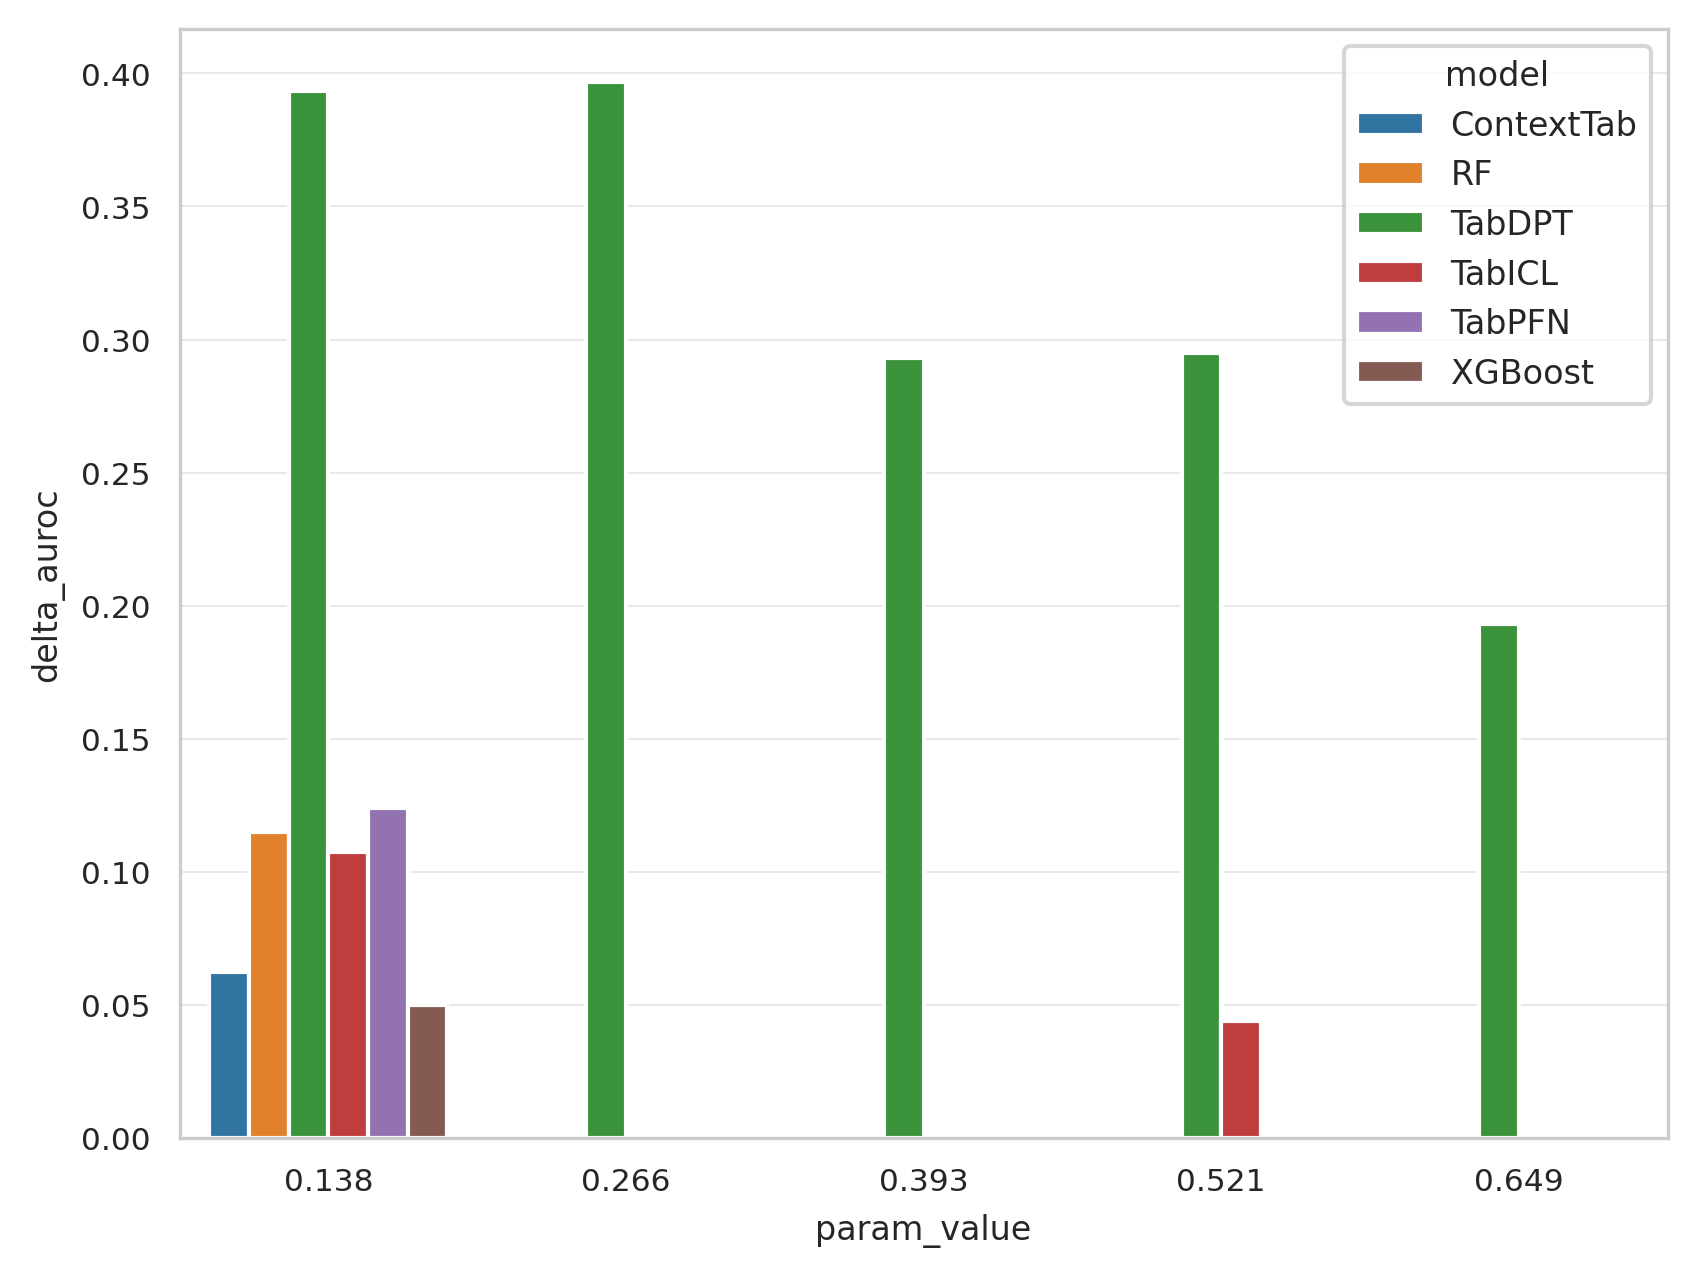

In [29]:
sns.set_style("whitegrid")
sns.barplot(data=stat_df_significant_dataset, x='param_value', y='delta_auroc', hue='model')

In [30]:
sorted(list(stat_df.model.unique()))

['ContextTab', 'RF', 'TabDPT', 'TabICL', 'TabPFN', 'XGBoost']

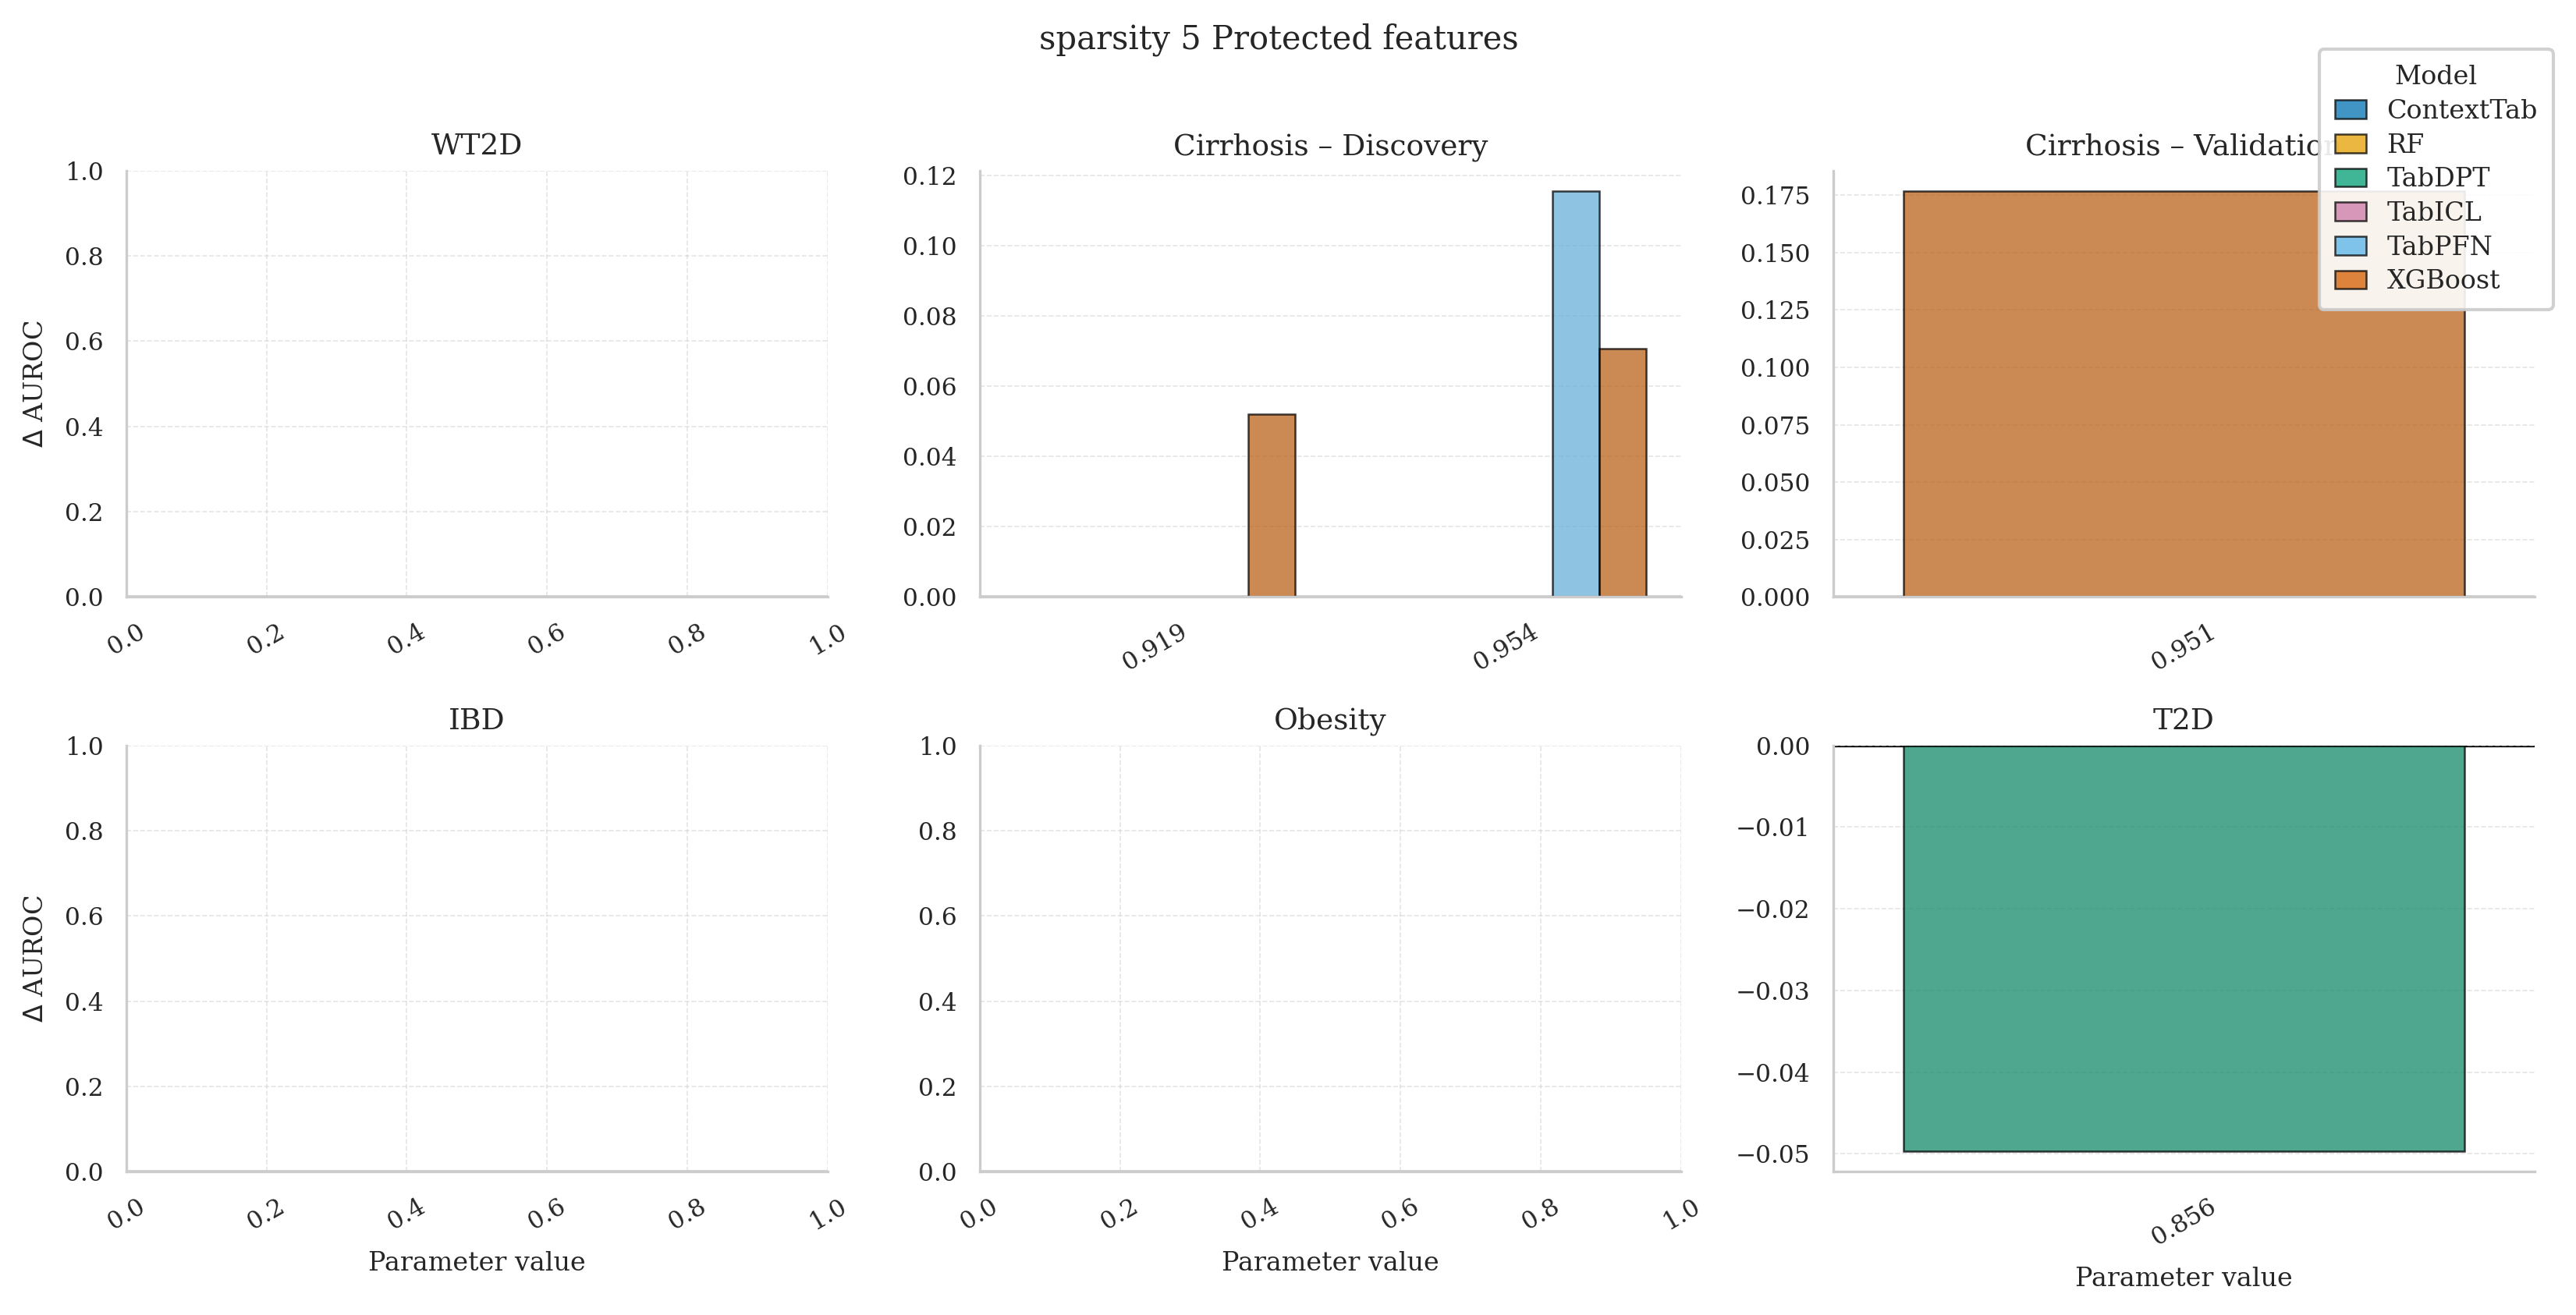

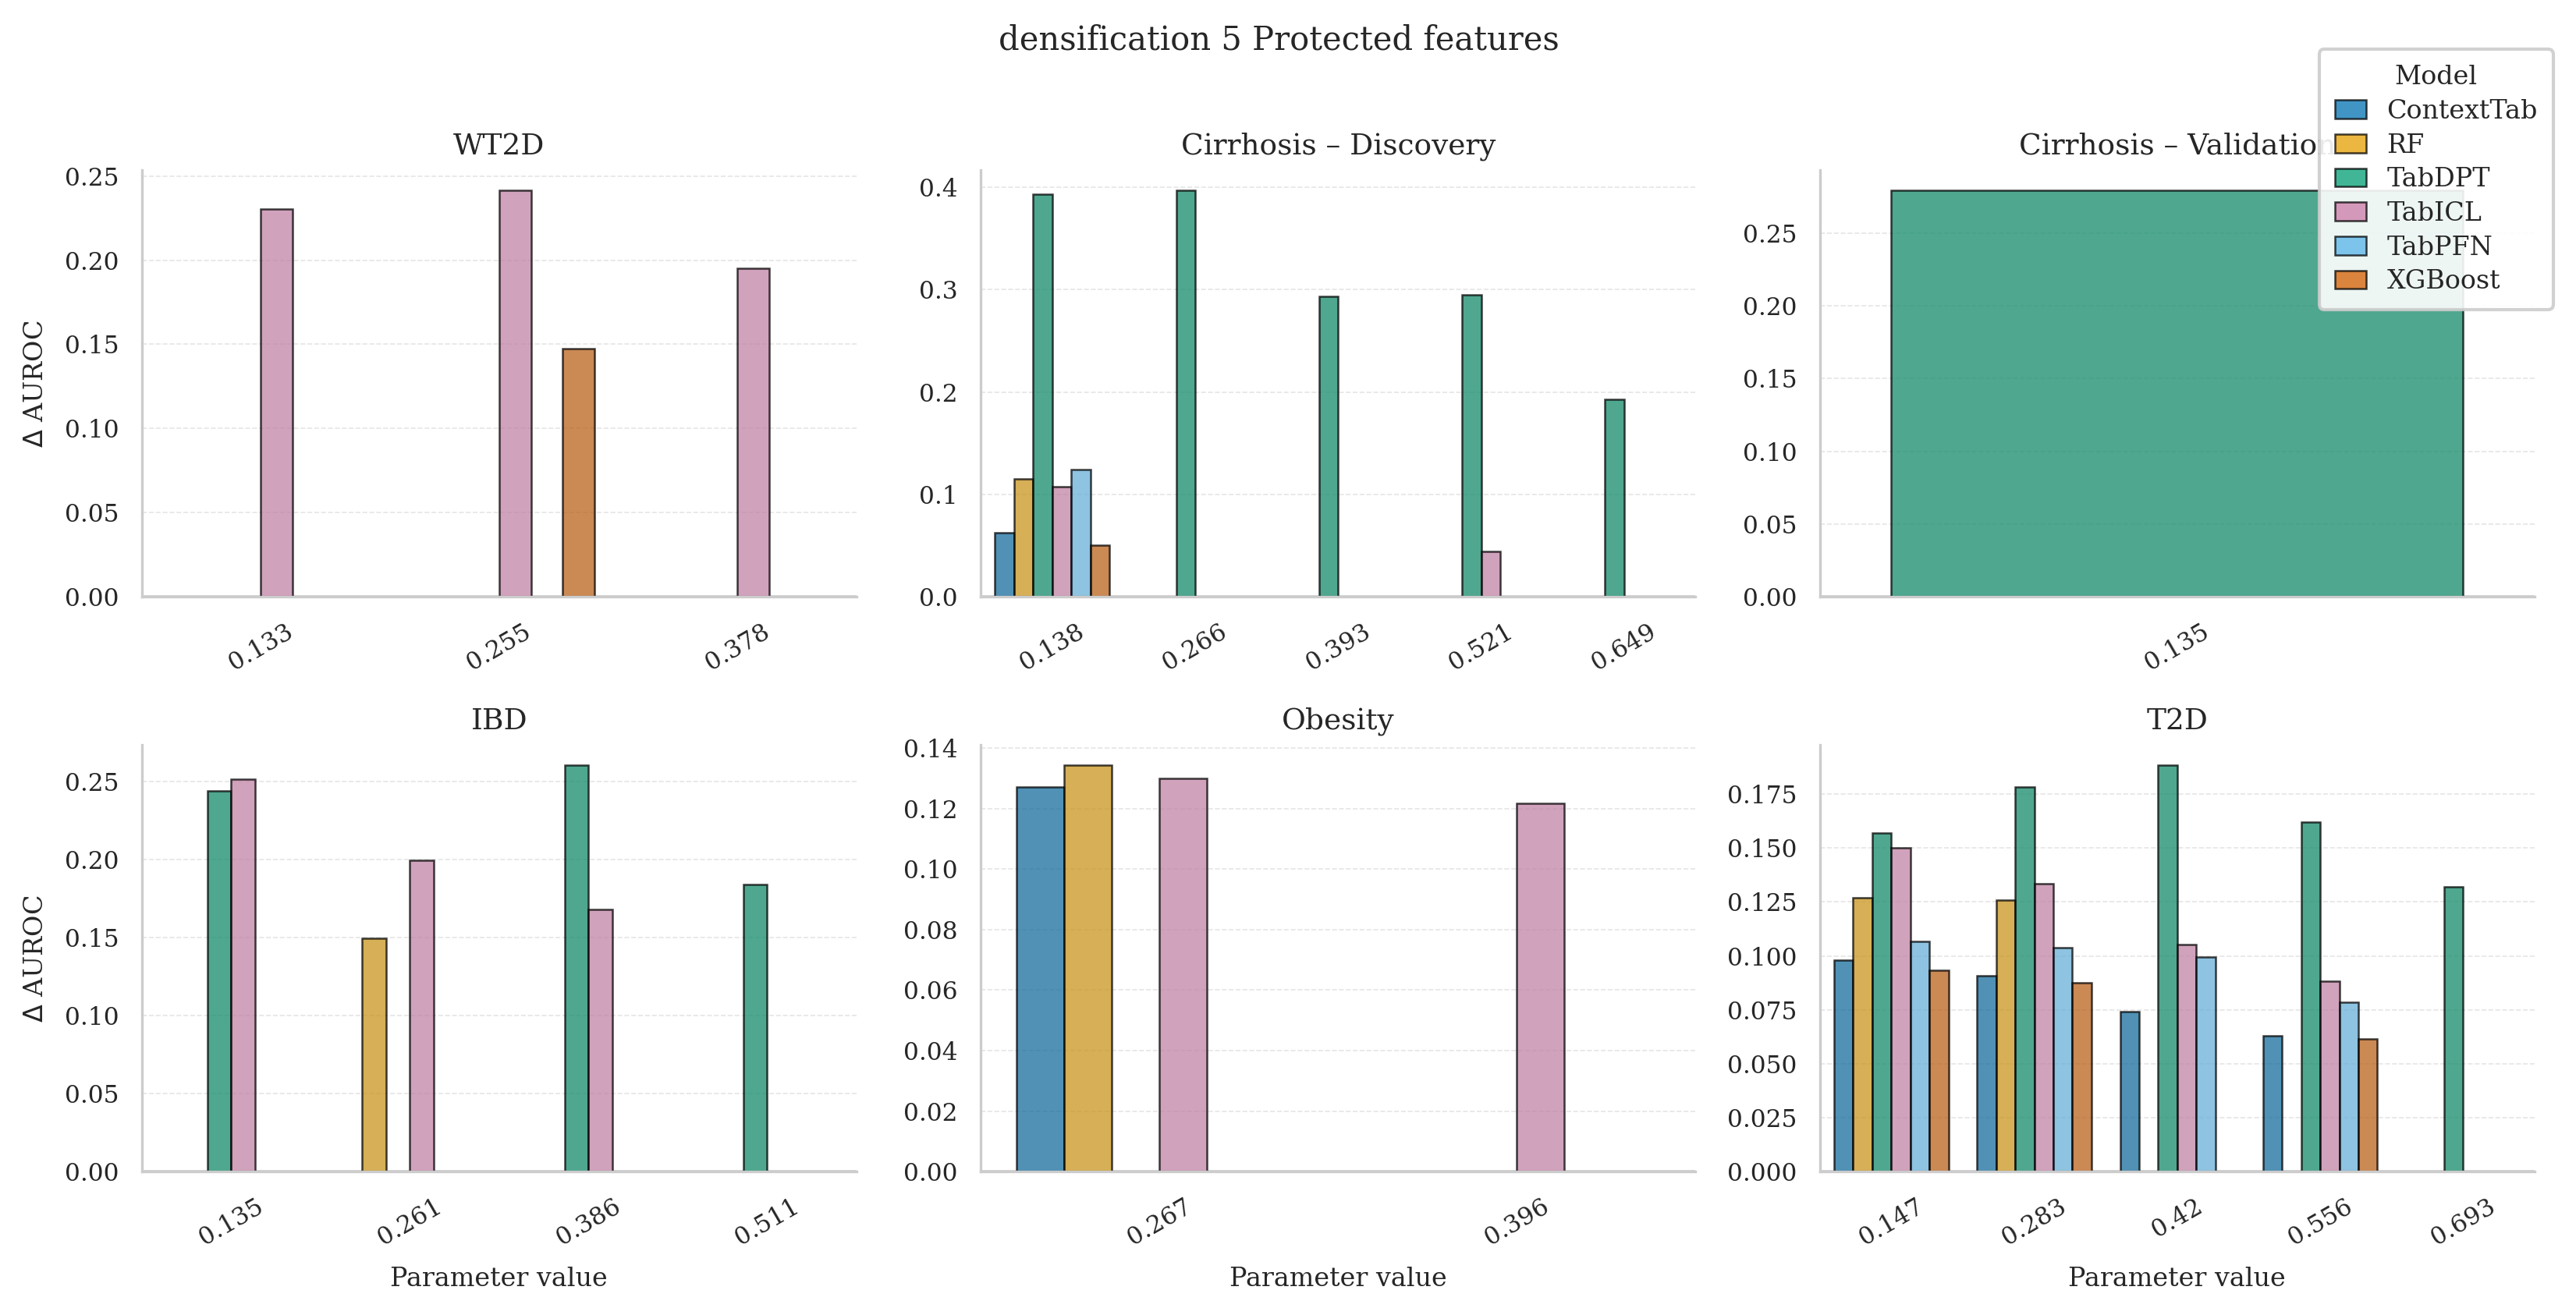

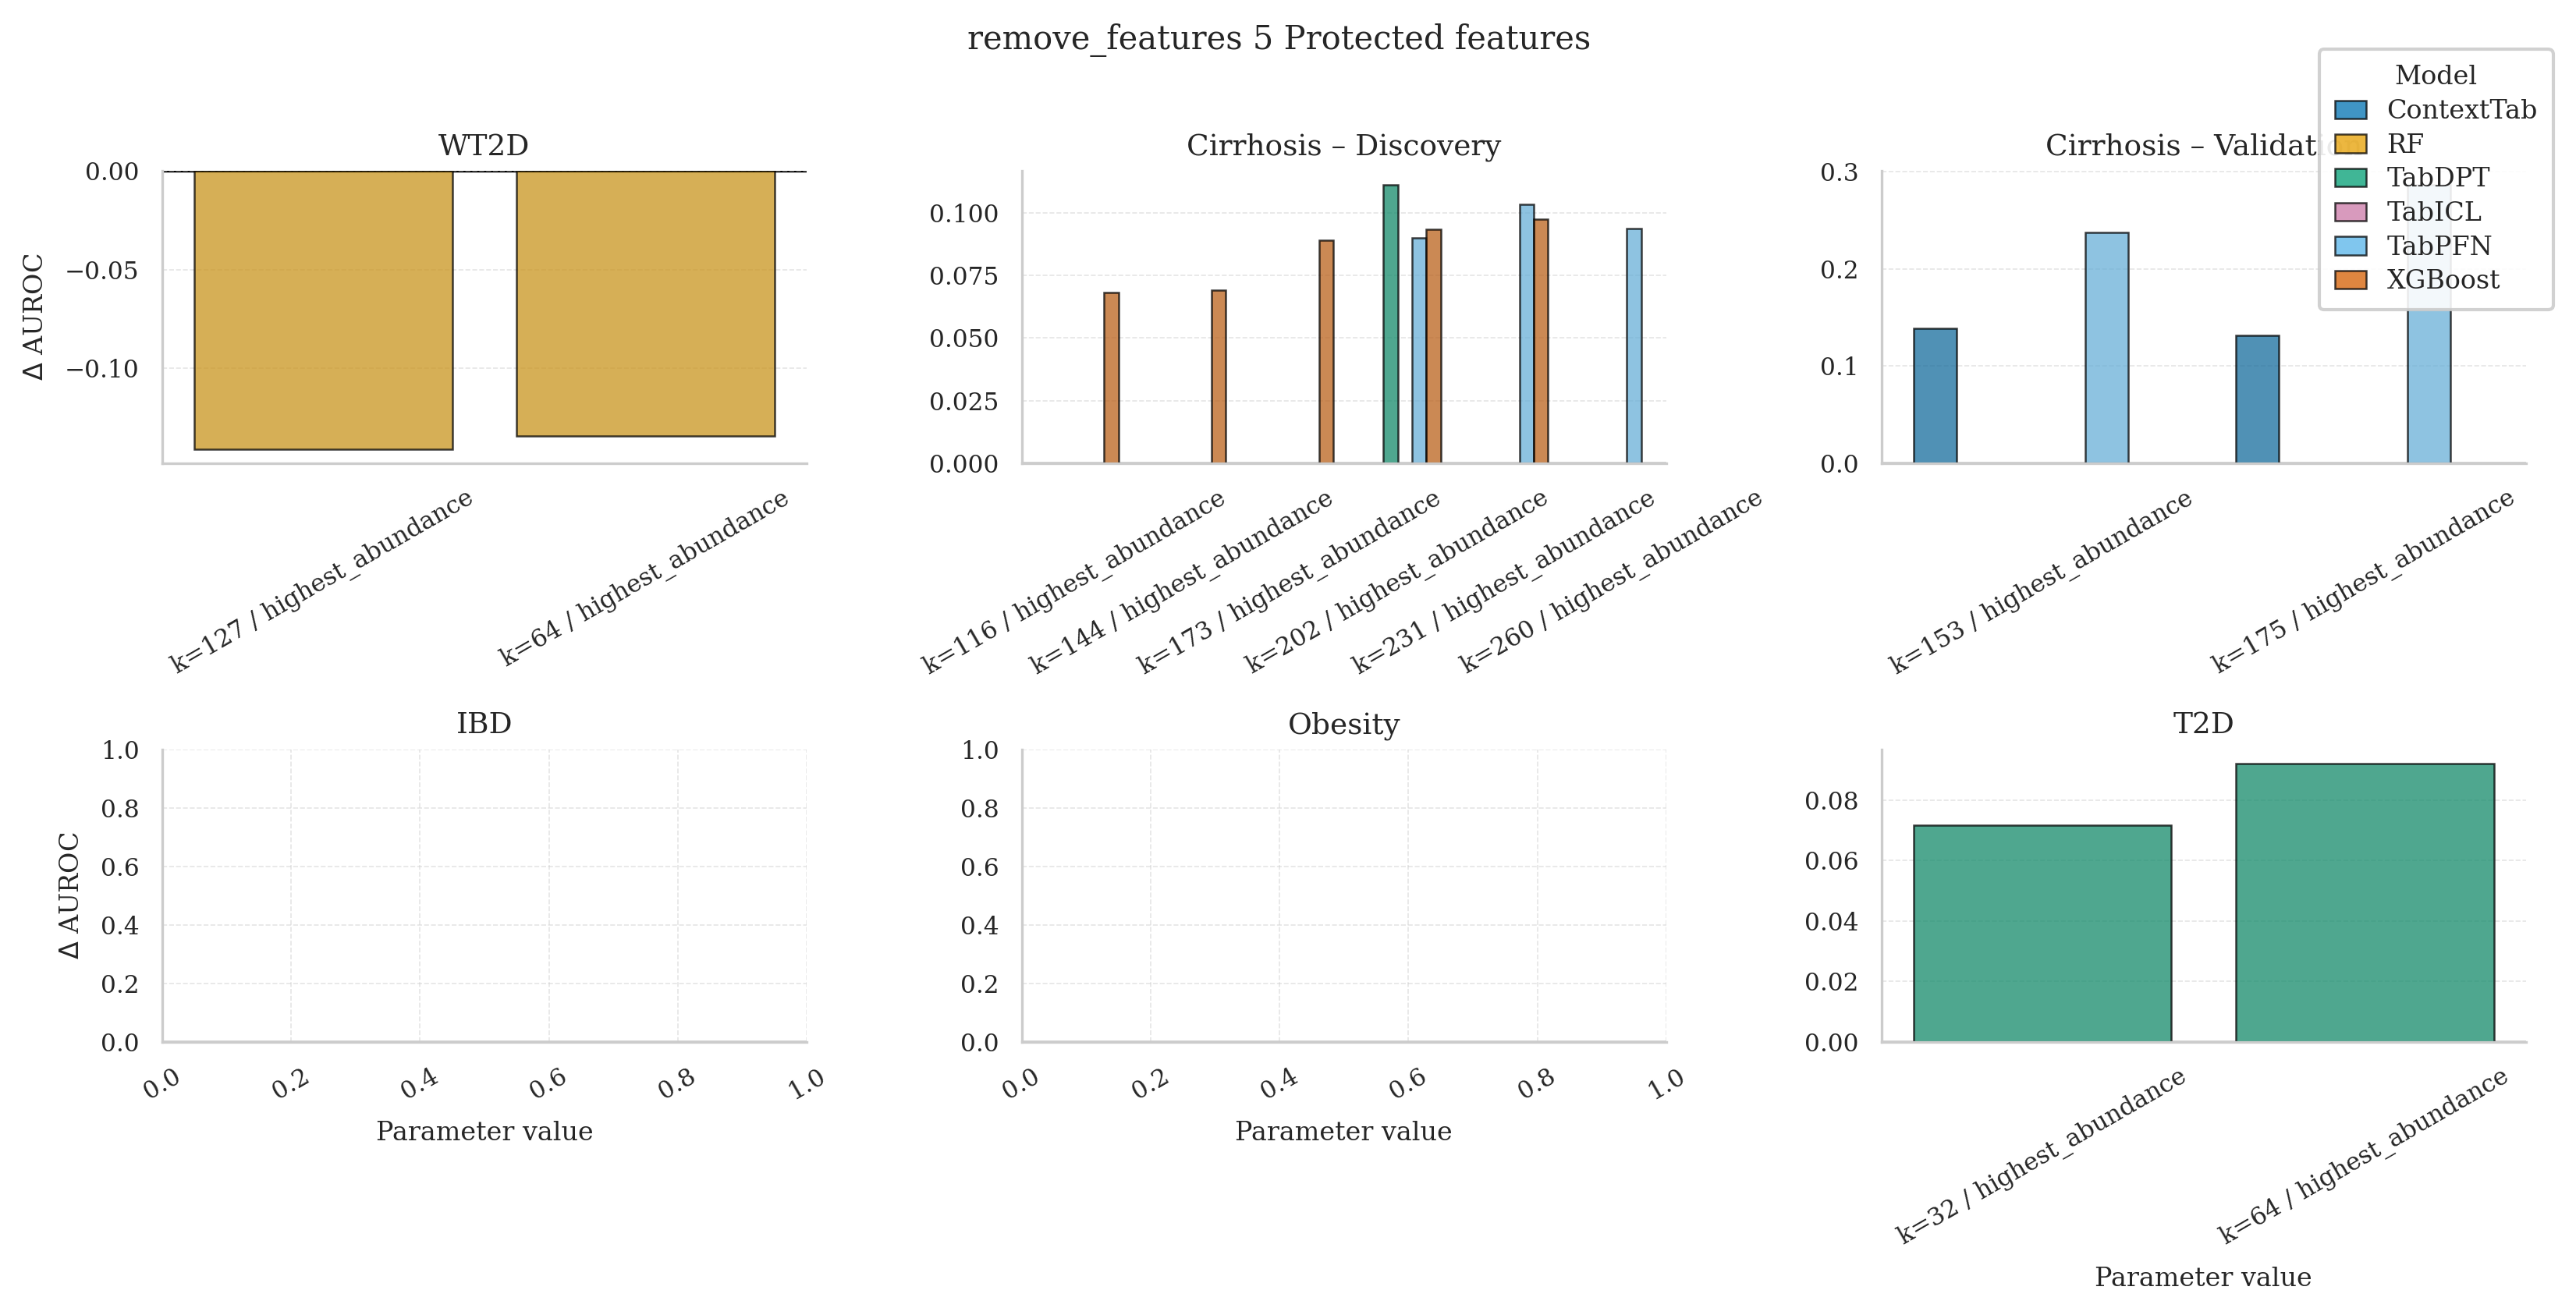

In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd

perturbations = ['sparsity', 'densification', 'remove_features']

for perturbation in perturbations:

    # ── Typography & style ────────────────────────────────────────────────────────
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "font.size": 9,
        "axes.titlesize": 9,
        "axes.labelsize": 8,
        "xtick.labelsize": 7.5,
        "ytick.labelsize": 7.5,
        "legend.fontsize": 8,
        "legend.title_fontsize": 8,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "axes.grid": True,
        "grid.linewidth": 0.4,
        "grid.linestyle": "--",
        "grid.alpha": 0.5,
        "grid.color": "#cccccc",
    })

    # ── Palette colorblind-safe (Wong 2011) ───────────────────────────────────────
    PALETTE = {
        'ContextTab': '#0072B2',
        'RF': '#E69F00',
        'TabDPT': '#009E73',
        'TabICL': '#CC79A7',
        'TabPFN': '#56B4E9',
        'XGBoost': '#D55E00',
    }

    ALL_MODELS = list(PALETTE.keys())  # ordine fisso, sempre lo stesso

    # ── Dataset list & pretty labels ──────────────────────────────────────────────
    DATASETS = [
        "abundance_WT2D",
        "abundance_cirrhosis--stagediscovery",
        "abundance_cirrhosis--stagevalidation",
        "abundance_ibd",
        "abundance_obesity",
        "abundance_t2d",
    ]

    LABELS = {
        "abundance_WT2D": "WT2D",
        "abundance_cirrhosis--stagediscovery": "Cirrhosis – Discovery",
        "abundance_cirrhosis--stagevalidation": "Cirrhosis – Validation",
        "abundance_ibd": "IBD",
        "abundance_obesity": "Obesity",
        "abundance_t2d": "T2D",
    }

    # ── 3 × 2 grid ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(11, 5.5), sharey=False)

    for ax, dataset in zip(axes.flat, DATASETS):
        df = stat_df_significant[
            (stat_df_significant["perturbation"] == perturbation) &
            (stat_df_significant["dataset"] == dataset)
            ][["param_value", "delta_auroc", "model"]]

        dataset_param_order = sorted(df["param_value"].unique())

        # Palette passata come lista ordinata secondo ALL_MODELS —
        # il colore di ogni modello è sempre lo stesso indipendentemente
        # da quali modelli sono presenti nel pannello
        sns.barplot(
            data=df,
            x="param_value",
            y="delta_auroc",
            hue="model",
            palette=PALETTE,  # dizionario: seaborn mappa model → colore direttamente
            order=dataset_param_order,
            hue_order=ALL_MODELS,
            errorbar="se",
            capsize=0.06,
            err_kws={"linewidth": 0.9, "color": "black"},
            edgecolor="black",
            linewidth=0.6,
            alpha=0.75,
            ax=ax,
            legend=False,
        )

        ax.axhline(0, color="black", linewidth=0.8, linestyle="-", zorder=0)
        ax.set_title(LABELS[dataset], pad=5)

        row, col = divmod(DATASETS.index(dataset), 3)
        ax.set_ylabel(r"$\Delta$ AUROC" if col == 0 else "", labelpad=5)
        ax.set_xlabel("Parameter value" if row == 1 else "", labelpad=5)

        ax.tick_params(axis="x", rotation=30)

    # ── Legenda condivisa — tutti i modelli con colore fisso ─────────────────────
    legend_handles = [
        mpatches.Patch(
            facecolor=color,
            edgecolor="black",
            linewidth=0.6,
            alpha=0.75,
            label=model,
        )
        for model, color in PALETTE.items()
    ]

    fig.legend(
        handles=legend_handles,
        title="Model",
        frameon=True,
        framealpha=0.9,
        edgecolor="#cccccc",
        borderpad=0.6,
        labelspacing=0.35,
        handlelength=1.2,
        loc="upper right",
        bbox_to_anchor=(1.0, 1.0),
    )

    fig.suptitle(perturbation + ' 5 Protected features', fontsize=10, y=1.01)
    plt.tight_layout()
    plt.savefig(f"paper_barplot_{perturbation}.pdf", bbox_inches="tight")
    plt.savefig(f"paper_barplot_{perturbation}.png", bbox_inches="tight")
    plt.show()

In [32]:
stat_df_significant[stat_df_significant.dataset == 'abundance_ibd']

,dataset,model,perturbation,param_value,auroc_baseline,auroc_ood,delta_auroc,p_value,p_value_fdr,significant
381,abundance_ibd,RF,densification,0.261,0.8762,0.7268,0.1494,0.0034,0.040131,True
400,abundance_ibd,TabDPT,densification,0.135,0.7986,0.5548,0.2438,0.0007,0.014400,True
402,abundance_ibd,TabDPT,densification,0.386,0.7986,0.5384,0.2602,0.0001,0.003600,True
403,abundance_ibd,TabDPT,densification,0.511,0.7986,0.6146,0.1840,0.0040,0.045000,True
420,abundance_ibd,TabICL,densification,0.135,0.8739,0.6226,0.2513,0.0000,0.000000,True
421,abundance_ibd,TabICL,densification,0.261,0.8739,0.6744,0.1995,0.0002,0.006545,True
422,abundance_ibd,TabICL,densification,0.386,0.8739,0.7059,0.1680,0.0015,0.022979,True


In [33]:
import pandas as pd
import numpy as np

df = pd.read_csv('/data/projects/deepintegromics/analyses/3.tabpfn/metagen_foundation_models/data_transformations/results/metrics_all.csv')

# baseline è uguale per tutti i param_value — prendi solo il primo
df_base = df.groupby(['dataset', 'model', 'fold'])

In [34]:
df_base.head()

,dataset,model,perturbation,param_key,param_value,fold,baseline_auroc,baseline_f1,baseline_prec,baseline_rec,auroc,f1,prec,rec
0,abundance_WT2D,ContextTab,densification,target_sparsity,0.623,0,0.6869,0.6957,0.6667,0.7273,0.6566,0.7857,0.6471,1.0000
1,abundance_WT2D,ContextTab,densification,target_sparsity,0.623,1,0.8111,0.8000,0.8000,0.8000,0.7500,0.6429,0.5000,0.9000
2,abundance_WT2D,ContextTab,densification,target_sparsity,0.623,2,0.7167,0.7273,0.6667,0.8000,0.7556,0.7692,0.6250,1.0000
3,abundance_WT2D,ContextTab,densification,target_sparsity,0.623,3,0.9261,0.8182,0.8182,0.8182,0.9034,0.7857,0.6471,1.0000
4,abundance_WT2D,ContextTab,densification,target_sparsity,0.623,4,0.7216,0.7273,0.7273,0.7273,0.7273,0.7500,0.6923,0.8182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3145,abundance_t2d,TabDPT,densification,target_sparsity,0.147,0,0.6504,0.5672,0.5758,0.5588,0.4958,0.6602,0.4928,1.0000
3146,abundance_t2d,TabDPT,densification,target_sparsity,0.147,1,0.6790,0.6197,0.5946,0.6471,0.5950,0.6667,0.5000,1.0000
3147,abundance_t2d,TabDPT,densification,target_sparsity,0.147,2,0.7849,0.7273,0.6512,0.8235,0.4034,0.6602,0.4928,1.0000
3148,abundance_t2d,TabDPT,densification,target_sparsity,0.147,3,0.7613,0.7077,0.7419,0.6765,0.5571,0.6471,0.4853,0.9706


In [35]:
import pandas as pd
import numpy as np

df = pd.read_csv('/data/projects/deepintegromics/analyses/3.tabpfn/metagen_foundation_models/data_transformations/results/metrics_all.csv')

df_base = df.groupby(['dataset', 'model', 'fold']).first().reset_index()

stats = df_base.groupby(['dataset', 'model'])['baseline_auroc'].agg(['mean','std']).reset_index()

mean_table = stats.pivot(index='model', columns='dataset', values='mean')
std_table  = stats.pivot(index='model', columns='dataset', values='std')

col_order = [
    'abundance_cirrhosis--stagediscovery',
    'abundance_cirrhosis--stagevalidation',
    'abundance_ibd',
    'abundance_obesity',
    'abundance_t2d',
    'abundance_WT2D',
]
mean_table = mean_table[col_order]
std_table  = std_table[col_order]

col_names = ['Cirrhosis disc.', 'Cirrhosis val.', 'IBD', 'Obesity', 'T2D', 'WT2D']
mean_table.columns = col_names
std_table.columns  = col_names

# ordine modelli: ML prima, poi TFM
ml_models  = ['RF', 'XGBoost']
tfm_models = ['ContextTab', 'TabDPT', 'TabICL', 'TabPFN']
model_order = ml_models + tfm_models

mean_table = mean_table.loc[model_order]
std_table  = std_table.loc[model_order]

# best per colonna su tutti i modelli
best = mean_table.idxmax(axis=0)

cell_table = pd.DataFrame(index=model_order, columns=col_names)
for col in col_names:
    for model in model_order:
        m = mean_table.loc[model, col] * 100
        s = std_table.loc[model, col]  * 100
        val = f"{m:.1f} $\\pm$ {s:.1f}"
        if model == best[col]:
            val = f"\\textbf{{{m:.1f}}} $\\pm$ {s:.1f}"
        cell_table.loc[model, col] = val

# LaTeX con linee verticali e \midrule tra ML e TFM
lines = []
lines.append(r'\begin{table*}[ht]')
lines.append(r'\centering')
lines.append(r'\caption{Baseline AUROC (mean $\pm$ std) across 5-fold CV on original data.}')
lines.append(r'\label{tab:baseline_auroc}')
lines.append(r'\begin{tabular}{l|c|c|c|c|c|c}')
lines.append(r'\toprule')
lines.append('Model & ' + ' & '.join(col_names) + r' \\')
lines.append(r'\midrule')
for model in model_order:
    row = ' & '.join(cell_table.loc[model].values)
    lines.append(f'{model} & {row} \\\\')
    if model == 'XGBoost':
        lines.append(r'\midrule')
lines.append(r'\bottomrule')
lines.append(r'\end{tabular}')
lines.append(r'\end{table*}')

print('\n'.join(lines))

\begin{table*}[ht]
\centering
\caption{Baseline AUROC (mean $\pm$ std) across 5-fold CV on original data.}
\label{tab:baseline_auroc}
\begin{tabular}{l|c|c|c|c|c|c}
\toprule
Model & Cirrhosis disc. & Cirrhosis val. & IBD & Obesity & T2D & WT2D \\
\midrule
RF & 93.5 $\pm$ 3.3 & \textbf{95.9} $\pm$ 6.0 & 88.6 $\pm$ 6.4 & 65.0 $\pm$ 2.9 & 72.4 $\pm$ 7.3 & 66.2 $\pm$ 10.1 \\
XGBoost & 93.1 $\pm$ 3.2 & 88.6 $\pm$ 8.9 & 75.8 $\pm$ 10.3 & 63.6 $\pm$ 5.7 & 69.0 $\pm$ 7.4 & 68.3 $\pm$ 13.6 \\
\midrule
ContextTab & 93.7 $\pm$ 2.7 & 95.0 $\pm$ 6.7 & 90.3 $\pm$ 5.4 & 66.8 $\pm$ 3.6 & 75.4 $\pm$ 6.9 & 77.2 $\pm$ 9.8 \\
TabDPT & 87.7 $\pm$ 7.4 & 77.2 $\pm$ 10.7 & 80.2 $\pm$ 11.8 & 62.0 $\pm$ 7.9 & 69.4 $\pm$ 7.9 & 57.2 $\pm$ 11.7 \\
TabICL & \textbf{94.5} $\pm$ 2.9 & 92.1 $\pm$ 4.8 & 88.7 $\pm$ 7.1 & \textbf{70.4} $\pm$ 6.1 & \textbf{76.6} $\pm$ 7.0 & \textbf{81.9} $\pm$ 15.3 \\
TabPFN & 92.5 $\pm$ 2.8 & 94.5 $\pm$ 6.4 & \textbf{91.8} $\pm$ 5.7 & 63.7 $\pm$ 4.5 & 73.1 $\pm$ 7.7 & 74.3 $\pm$ 15.4 \\


In [ ]:
### CODICE USATO PER SELEZIONARE LE PROTECTED FEATURES PER CIASCUN DATASET

import sys
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

sys.path.append('/data/projects/deepintegromics/analyses/3.tabpfn/metagen_foundation_models/')
from data_generation.data_generator import DataGenerator

DATASETS = [
    'abundance_cirrhosis--stagediscovery',
    'abundance_cirrhosis--stagevalidation',
    'abundance_obesity',
    'abundance_ibd',
    'abundance_t2d',
    'abundance_WT2D',
]

CV = 5
SEED = 42
THRESHOLD = 0.03


def get_anova_ranking(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    selector = SelectKBest(f_classif, k='all')
    selector.fit(X, y)
    scores = np.nan_to_num(selector.scores_)
    return np.argsort(scores)[::-1]


def cv_auroc_rf(X: np.ndarray, y: np.ndarray) -> float:
    skf = StratifiedKFold(n_splits=CV, shuffle=True, random_state=SEED)
    scores = []
    for train_idx, test_idx in skf.split(X, y):
        rf = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
        rf.fit(X[train_idx], y[train_idx])
        proba = rf.predict_proba(X[test_idx])[:, 1]
        scores.append(roc_auc_score(y[test_idx], proba))
    return np.mean(scores), np.std(scores)


# =============================================================================
# MAIN
# =============================================================================

protect_rows = []

for dataset in DATASETS:
    print(f"\n{'=' * 50}")
    print(f"Dataset: {dataset}")
    print(f"{'=' * 50}")

    gen = DataGenerator(generator_type='densification', data_source='pasolli')
    gen.load_data(dataset)
    X = gen.X_original.values
    y = gen.y_original.values
    print(f"  Shape: {X.shape}")

    ranked_idx = get_anova_ranking(X, y)

    # baseline k=0
    auroc_baseline, _ = cv_auroc_rf(X, y)
    print(f"  k= 0 removed -> AUROC = {auroc_baseline * 100:.1f}%")
    print(f"  Threshold: baseline - {THRESHOLD * 100:.0f}% = {(auroc_baseline - THRESHOLD) * 100:.1f}%")

    n_protect = 0
    for k in range(1, X.shape[1] + 1):
        mask = np.ones(X.shape[1], dtype=bool)
        mask[ranked_idx[:k]] = False
        X_sub = X[:, mask]

        mean_auc, std_auc = cv_auroc_rf(X_sub, y)
        print(f"  k={k:2d} removed -> AUROC = {mean_auc * 100:.1f} +/- {std_auc * 100:.1f}")

        if (auroc_baseline - mean_auc) >= THRESHOLD:
            n_protect = max(0, k - 1)
            print(f"\n  -> Degradation >= {THRESHOLD * 100:.0f}% at k={k}")
            print(f"  -> n_features_protect = {n_protect}")
            break

    protect_rows.append({
        'dataset': dataset,
        'auroc_baseline': round(auroc_baseline, 4),
        'first_k_degraded': k,
        'n_features_protect': n_protect,
    })

# =============================================================================
# RESULTS
# =============================================================================
protect_df = pd.DataFrame(protect_rows)
protect_df.to_csv('ablation_protected.csv', index=False)
print("\n\nProtected features per dataset:")
print(protect_df.to_string(index=False))

In [ ]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

sys.path.append('/data/projects/deepintegromics/analyses/3.tabpfn/metagen_foundation_models/')
from data_generation.data_generator import DataGenerator

# =====================================================================
# GLOBAL A4 PLOT SETTINGS
# =====================================================================
plt.rcParams.update({
    "figure.figsize": (16, 11),   # A4-ish landscape
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "lines.linewidth": 2.5,
    "lines.markersize": 8,
})

DATASETS = [
    'abundance_cirrhosis--stagediscovery',
    'abundance_cirrhosis--stagevalidation',
    'abundance_obesity',
    'abundance_ibd',
    'abundance_t2d',
    'abundance_WT2D',
]

K_VALUES  = list(range(0, 61))
CV        = 5
SEED      = 42
THRESHOLD = 0.03

DATASET_LABELS = {
    'abundance_WT2D':                       'WT2D',
    'abundance_cirrhosis--stagediscovery':  'Cirrhosis 1',
    'abundance_cirrhosis--stagevalidation': 'Cirrhosis 2',
    'abundance_ibd':                        'IBD',
    'abundance_obesity':                    'Obesity',
    'abundance_t2d':                        'T2D',
}

def get_anova_ranking(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    selector = SelectKBest(f_classif, k='all')
    selector.fit(X, y)
    scores = np.nan_to_num(selector.scores_)
    return np.argsort(scores)[::-1]

def cv_auroc_rf(X: np.ndarray, y: np.ndarray) -> tuple:
    skf = StratifiedKFold(n_splits=CV, shuffle=True, random_state=SEED)
    scores = []
    for train_idx, test_idx in skf.split(X, y):
        rf = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
        rf.fit(X[train_idx], y[train_idx])
        proba = rf.predict_proba(X[test_idx])[:, 1]
        scores.append(roc_auc_score(y[test_idx], proba))
    return np.mean(scores), np.std(scores), scores

def find_first_degradation_k(auroc_baseline: float, means: list, threshold: float) -> int:
    for k_idx, mean_auc in enumerate(means):
        if k_idx == 0:
            continue
        if (auroc_baseline - mean_auc) >= threshold:
            return k_idx
    return len(means) - 1

# =====================================================================
# MAIN
# =====================================================================

rows         = []
protect_rows = []

fig, axes = plt.subplots(2, 3, figsize=(16, 11))
axes = axes.flatten()

for ax_idx, dataset in enumerate(DATASETS):
    print(f"\n{'='*50}")
    print(f"Dataset: {dataset}")
    print(f"{'='*50}")

    gen = DataGenerator(generator_type='zero_imputation', data_source='pasolli')
    gen.load_data(dataset)
    X = gen.X_original.values
    y = gen.y_original.values
    print(f"  Shape: {X.shape}")

    ranked_idx = get_anova_ranking(X, y)

    means, stds = [], []

    for k in K_VALUES:
        if k == 0:
            X_sub = X
        else:
            mask = np.ones(X.shape[1], dtype=bool)
            mask[ranked_idx[:k]] = False
            X_sub = X[:, mask]

        mean_auc, std_auc, fold_vals = cv_auroc_rf(X_sub, y)
        means.append(mean_auc)
        stds.append(std_auc)
        print(f"  k={k:2d} removed -> AUROC = {mean_auc*100:.1f} +/- {std_auc*100:.1f}")

        for fold_i, val in enumerate(fold_vals):
            rows.append({
                'dataset':   dataset,
                'k_removed': k,
                'fold':      fold_i,
                'auroc':     round(val, 4),
            })

    auroc_baseline = means[0]

    first_k = find_first_degradation_k(auroc_baseline, means, THRESHOLD)
    n_protect = max(0, first_k - 1)

    print(f"\n  Baseline AUROC       : {auroc_baseline*100:.1f}%")
    print(f"  Threshold            : {THRESHOLD*100:.0f}%")
    print(f"  First k >= 3% drop   : {first_k}")
    print(f"  -> n_features_protect = {n_protect}")

    protect_rows.append({
        'dataset':            dataset,
        'auroc_baseline':     round(auroc_baseline, 4),
        'first_k_degraded':   first_k,
        'n_features_protect': n_protect,
        'auroc_at_protect':   round(means[n_protect], 4),
        'delta_at_protect':   round(auroc_baseline - means[n_protect], 4),
    })

    # ---------------------------------------------------------------------
    # PLOT (UPDATED)
    # ---------------------------------------------------------------------
    ax = axes[ax_idx]

    # Tick size bigger
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)

    xticks = list(range(0, max(K_VALUES)+1, 5))
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks, rotation=45, ha='right')

    means_arr = np.array(means)
    stds_arr  = np.array(stds)

    # Blue dots smaller (markersize=4)
    ax.plot(K_VALUES, means_arr * 100, marker='o', color='#2196F3',
            linewidth=2.5, markersize=4, label='AUROC (RF)')

    ax.fill_between(
        K_VALUES,
        (means_arr - stds_arr) * 100,
        (means_arr + stds_arr) * 100,
        alpha=0.15, color='#2196F3'
    )

    ax.axhline(auroc_baseline * 100, color='gray',
               linestyle='--', linewidth=1.5, alpha=0.7)

    ax.axhline((auroc_baseline - THRESHOLD) * 100, color='red',
               linestyle=':', linewidth=2, alpha=0.9)

    ax.axvline(first_k, color='orange', linestyle='--',
               linewidth=2.2, alpha=0.9)

    if n_protect > 0:
        ax.axvline(n_protect, color='green', linestyle='--',
                   linewidth=2.2, alpha=0.9)

    # Bigger axis labels
    ax.set_xlabel('Top-k features removed (ANOVA)', fontsize=18)
    ax.set_ylabel('AUROC (%)', fontsize=18)

    ax.set_ylim(50, 100)

    ax.set_title(
        f"{DATASET_LABELS.get(dataset, dataset)}\n"
        f"n_features_protect = {n_protect}",
        fontweight='bold', fontsize=18
    )

    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(frameon=True, fontsize=14)

plt.tight_layout()
plt.show()

protect_df = pd.DataFrame(protect_rows)
print("\nProtected features per dataset:")
print(protect_df[['dataset', 'auroc_baseline', 'n_features_protect',
                   'auroc_at_protect', 'delta_at_protect']].to_string(index=False))

In [10]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# sys.path.append('/data/projects/deepintegromics/analyses/3.tabpfn/metagen_foundation_models/')
from data_generation.data_generator import DataGenerator

DATASETS = [
    'abundance_cirrhosis--stagediscovery',
    'abundance_cirrhosis--stagevalidation',
    'abundance_obesity',
    'abundance_ibd',
    'abundance_t2d',
    'abundance_WT2D',
]

for ax_idx, dataset in enumerate(DATASETS):
    print(f"\n{'='*50}")
    print(f"Dataset: {dataset}")
    print(f"{'='*50}")

    gen = DataGenerator(generator_type='zero_imputation', data_source='pasolli')
    gen.load_data(dataset)
    X = gen.X_original.values
    y = gen.y_original.values
    print(f"  Shape: {X.shape}")



Dataset: abundance_cirrhosis--stagediscovery


FileNotFoundError: [Errno 2] No such file or directory: '/pools/apollon/ummisco/data/projects/deepintegromics/analyses/3.tabpfn/metagen_foundation_models/datasets/data/abundance_cirrhosis--stagediscovery.txt'